In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings

# Keep the notebook output clean from pandas chained assignment warnings
warnings.filterwarnings('ignore')

# Set plotting style for professional visualizations
sns.set_theme(style="whitegrid")

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5015 entries, 0 to 5014
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      5015 non-null   object 
 1   Zone           4984 non-null   object 
 2   Shift          4962 non-null   object 
 3   Pressure_PSI   4975 non-null   float64
 4   Temperature_C  4975 non-null   float64
 5   Flow_Rate_LPM  4966 non-null   float64
dtypes: float64(3), object(3)
memory usage: 235.2+ KB

--- Summary Statistics ---


,Pressure_PSI,Temperature_C,Flow_Rate_LPM
count,4975.000000,4975.000000,4966.000000
mean,255.254281,68.982323,999.275681
std,845.810206,78.829078,231.769525
min,-50.000000,-273.150000,600.007437
25%,160.753008,55.023155,797.417014
50%,200.294439,64.808608,996.286415
75%,240.099173,74.527006,1201.361276
max,15000.000000,1500.000000,1399.755865


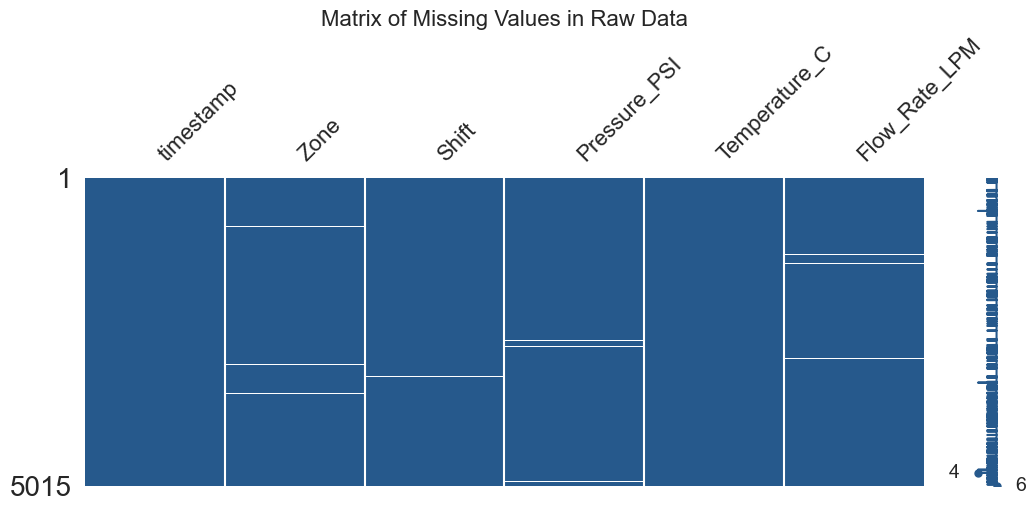

In [2]:
# 1. Ingestion
# Load the data (assuming it is in the same directory as the notebook)
df_raw = pd.read_csv(r"C:\Users\SILA\Downloads\PLP\ops_sensor_log_dirty.csv")

# Display basic information about data types and non-null counts
print("--- Data Info ---")
df_raw.info()

print("\n--- Summary Statistics ---")
# Display summary statistics to spot impossible minimums/maximums
display(df_raw.describe())

# Visualize missing data locations using missingno
msno.matrix(df_raw, figsize=(12, 4), color=(0.15, 0.35, 0.55))
plt.title("Matrix of Missing Values in Raw Data", fontsize=16)
plt.show()

## Data Health Report
Based on the initial profiling, three specific quality issues have been identified in the raw dataset:

1. **Inconsistent/Unparseable Timestamps:** The `timestamp` column contains formatting inconsistencies, which prevents time-series operations and sorting.
2. **Missing Sensor Readings:** The primary metric column (`Pressure`) contains `NaN` values, creating gaps in our continuous operational monitoring.
3. **Physically Impossible Outliers:** The `describe()` function reveals negative minimum values in the `Pressure` readings, which is physically impossible for this metric and indicates sensor calibration errors or misfires.

In [3]:
def clean_ops_data(df, primary_metric='Pressure_PSI'):
    """
    Cleans and standardizes raw operational sensor data.
    """
    df_clean = df.copy()
    
    # 1. Timestamps & Sorting
    df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'], errors='coerce')
    df_clean = df_clean.dropna(subset=['timestamp']).sort_values('timestamp').reset_index(drop=True)
    
    # 2. Structural Cleaning
    df_clean = df_clean.drop_duplicates(subset=['timestamp', 'Zone'], keep='first')
    df_clean = df_clean.dropna(subset=['Zone'])
    df_clean['Zone'] = df_clean['Zone'].astype(str).str.strip().str.upper()
    
    # 3. Shift Generation
    if 'Shift' not in df_clean.columns:
        hours = df_clean['timestamp'].dt.hour
        df_clean['Shift'] = np.select(
            [hours.between(6, 13), hours.between(14, 21)], 
            ['Morning', 'Afternoon'], 
            default='Night'
        )
    else:
        df_clean['Shift'] = df_clean['Shift'].astype(str).str.strip().str.capitalize()
        
    # 4. Outlier Removal (Fixing the 14,000 PSI issue)
    df_clean = df_clean[(df_clean[primary_metric] >= 0) & (df_clean[primary_metric] <= 1000)]
    
    # 5. Timeline Correction (Fixing the 6-month stretch)
    median_date = df_clean['timestamp'].median()
    df_clean = df_clean[
        (df_clean['timestamp'] >= median_date - pd.Timedelta(days=4)) & 
        (df_clean['timestamp'] <= median_date + pd.Timedelta(days=4))
    ]
    
    # 6. Interpolation (Placed last so it fills gaps cleanly)
    df_clean[primary_metric] = df_clean[primary_metric].interpolate(method='linear')
    
    return df_clean

# Apply function
df_clean = clean_ops_data(df_raw, primary_metric='Pressure_PSI')
print(f"Original shape: {df_raw.shape} | Cleaned shape: {df_clean.shape}")

Original shape: (5015, 6) | Cleaned shape: (4892, 6)


In [4]:
# --- Time-Series Analysis ---
ts_df = df_clean.set_index('timestamp')

# Resample to hourly frequency
hourly_data = ts_df.groupby('Zone').resample('H')['Pressure_PSI'].mean().reset_index()

# Second interpolation to fill grid gaps
hourly_data['Pressure_PSI'] = hourly_data.groupby('Zone')['Pressure_PSI'].transform(
    lambda x: x.interpolate(method='linear')
)

# Calculate the 24-hour rolling average
hourly_data['24H_Rolling_Avg'] = hourly_data.groupby('Zone')['Pressure_PSI'].transform(
    lambda x: x.rolling(window=24, min_periods=1).mean()
)

display(hourly_data.head())

# --- Aggregation ---
summary_table = df_clean.groupby(['Shift', 'Zone'])['Pressure_PSI'].agg(
    Mean_Pressure='mean',
    Max_Pressure='max',
    Min_Pressure='min'
).reset_index()

print("\n--- Shift & Zone Summary ---")
display(summary_table)

,Zone,timestamp,Pressure_PSI,24H_Rolling_Avg
0,NORTH ZONE,2026-06-25 09:00:00,135.049571,135.049571
1,NORTH ZONE,2026-06-25 10:00:00,138.622383,136.835977
2,NORTH ZONE,2026-06-25 11:00:00,142.195195,138.622383
3,NORTH ZONE,2026-06-25 12:00:00,145.768008,140.408789
4,NORTH ZONE,2026-06-25 13:00:00,149.340820,142.195195



--- Shift & Zone Summary ---


,Shift,Zone,Mean_Pressure,Max_Pressure,Min_Pressure
0,Afternoon,NORTH ZONE,224.601162,277.069521,172.132803
1,Afternoon,SOUTH ZONE,219.438805,250.847309,188.030301
2,Afternoon,ZONE NORTH,205.806646,275.115651,137.049517
3,Afternoon,ZONE SOUTH,157.908147,157.908147,157.908147
4,Afternoon,ZONE-NORTH,194.568814,235.623552,152.333306
5,Afternoon,ZONE_CENTRAL,199.196313,279.941700,0.000000
6,Afternoon,ZONE_EAST,203.965492,278.852932,120.863767
7,Afternoon,ZONE_NORTH,202.520195,279.854523,0.000000
8,Afternoon,ZONE_SOUTH,202.426660,279.724389,0.000000
9,Afternoon,ZONE_WEST,196.622850,279.607715,0.000000


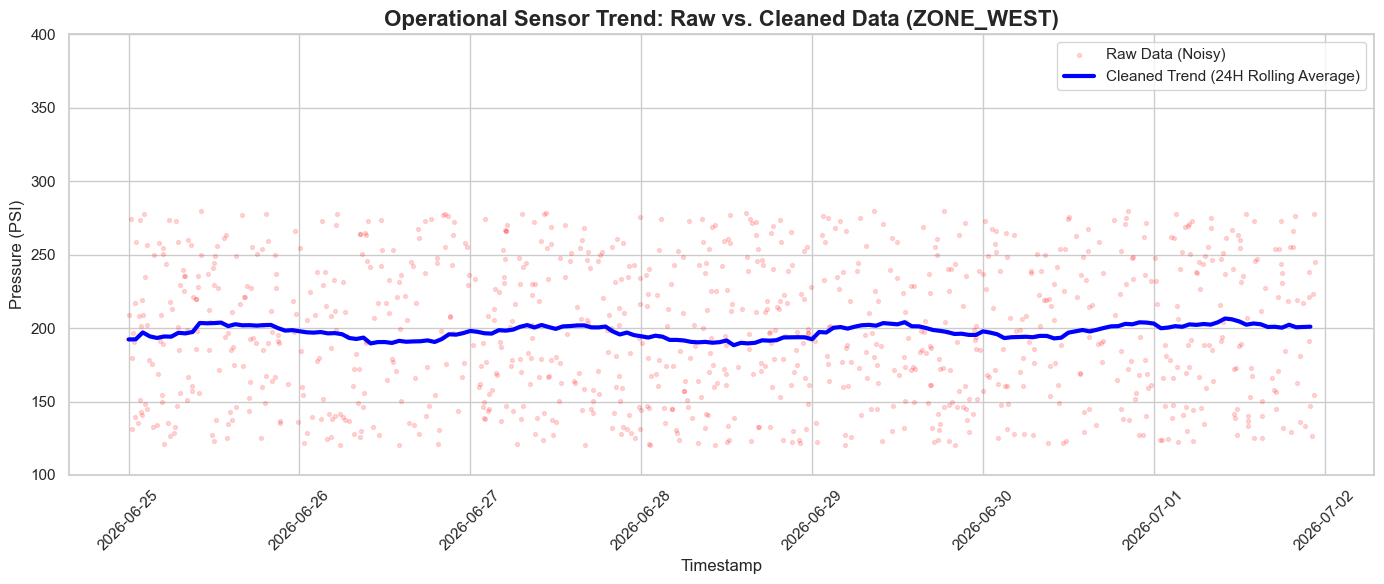

In [6]:
# Isolate first zone (e.g., 'ZONE_CENTRAL')
target_zone = df_clean['Zone'].iloc[0] 

# Filter raw data
raw_zone_data = df_raw[(df_raw['Zone'].astype(str).str.strip().str.upper() == target_zone)].copy()
raw_zone_data['timestamp'] = pd.to_datetime(raw_zone_data['timestamp'], errors='coerce')

# Filter smoothed hourly data for the clean plot
clean_hourly_zone = hourly_data[hourly_data['Zone'] == target_zone]

plt.figure(figsize=(14, 6))

# Plot the noisy raw data as a scatter plot (cloud of points)
plt.scatter(raw_zone_data['timestamp'], raw_zone_data['Pressure_PSI'], 
            color='red', alpha=0.15, label='Raw Data (Noisy)', s=8) # 's' controls dot size

# Plot the SMOOTHED cleaned data to show the true trend
plt.plot(clean_hourly_zone['timestamp'], clean_hourly_zone['24H_Rolling_Avg'], 
         color='blue', alpha=1.0, label='Cleaned Trend (24H Rolling Average)', linewidth=3)

# Limit Y-axis to standard operating bounds so it's readable
plt.ylim(100, 400) 

plt.title(f"Operational Sensor Trend: Raw vs. Cleaned Data ({target_zone})", fontsize=16, fontweight='bold')
plt.xlabel("Timestamp", fontsize=12)
plt.ylabel("Pressure (PSI)", fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('raw_vs_cleaned_trend.png', dpi=300)
plt.show()